## Result Int

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Reading results

In [44]:
res_path = '.'
target_files = list(os.listdir(res_path))[-2:]

extract_res = lambda target_index, res_path='.': pd.read_csv(os.path.join(res_path, target_files[target_index]))

## Visualization of results

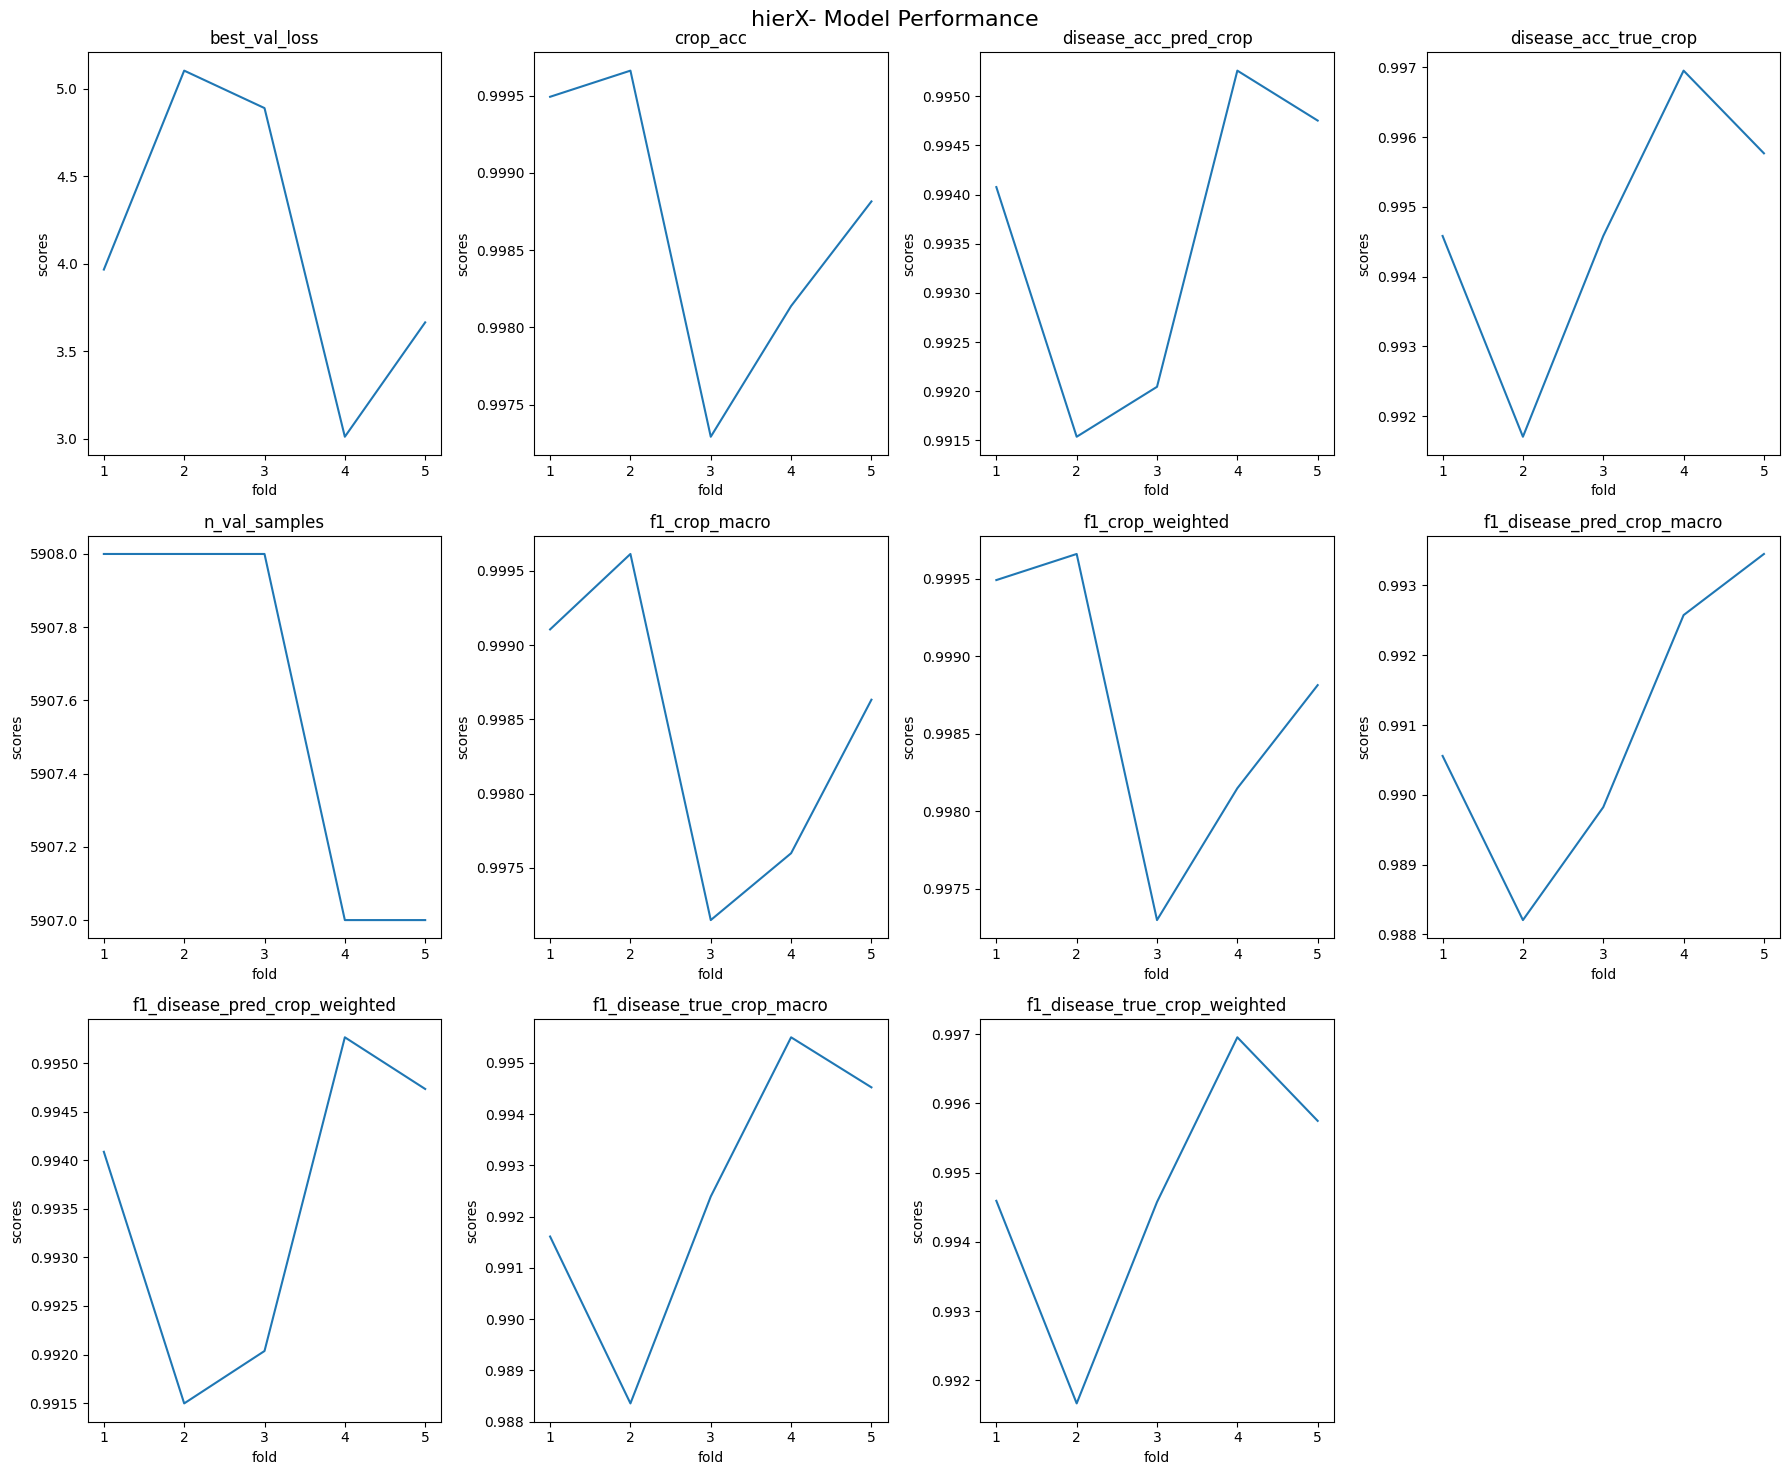

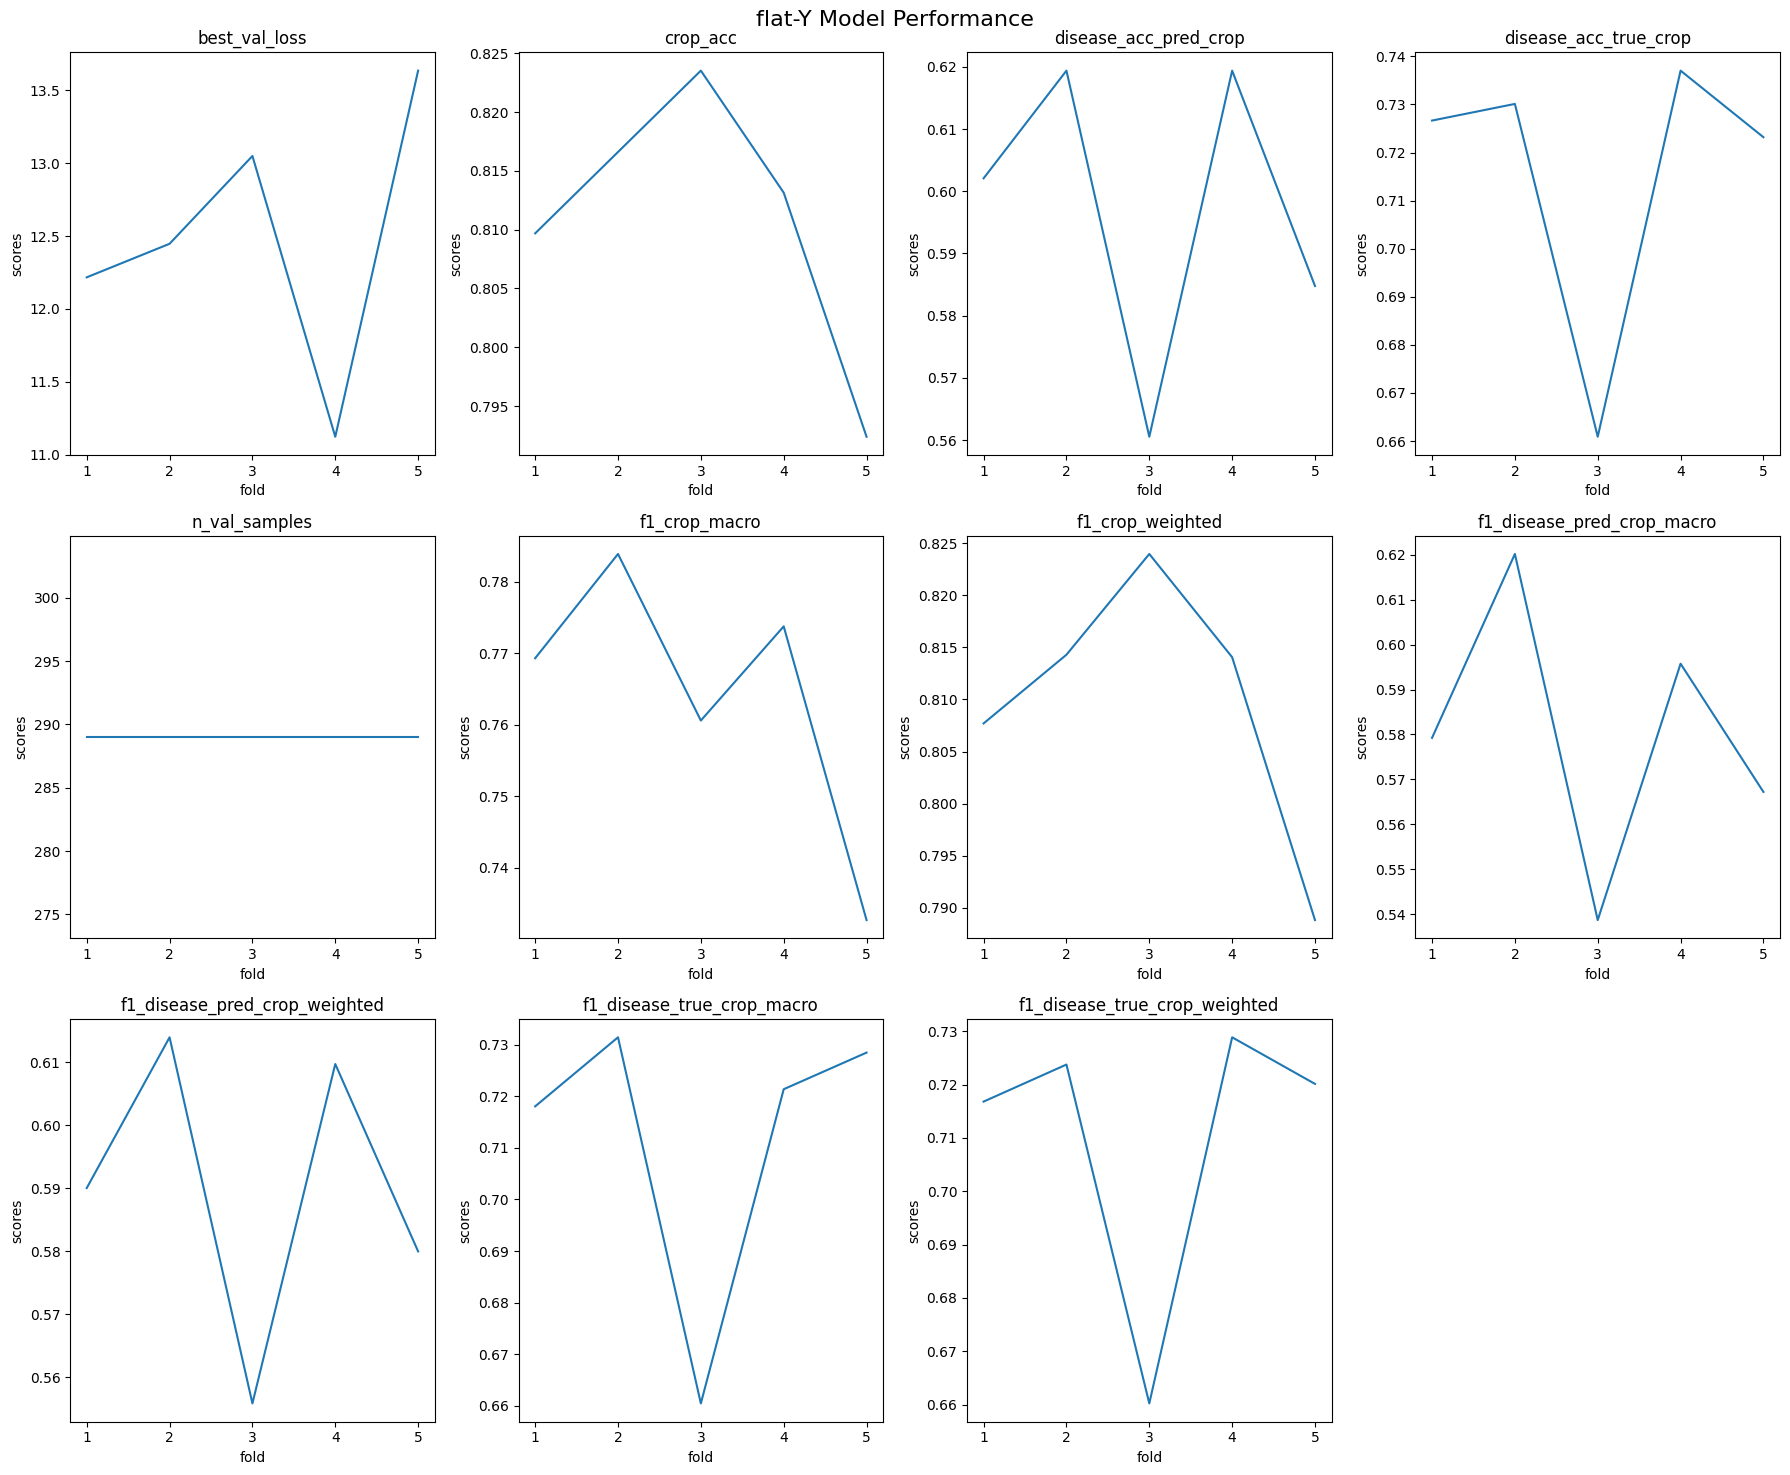

In [51]:
def plot_results(result_df, title, filename):
    x_dim = 'fold'
    x = result_df[x_dim]
    cols = list(result_df.columns)
    cols.remove(x_dim)

    fig, axes = plt.subplots(3, 4, figsize=(18, 15))
    axes = axes.flatten()
    for i, col in enumerate(cols):
        y = result_df[col]
        axes[i].plot(x, y)
        axes[i].set_title(col)
        axes[i].set_xlabel(x_dim)
        axes[i].set_ylabel('scores')
    axes[-1].axis('off')
    fig.suptitle(title, fontsize=16)
    fig.savefig(f'{filename}.png')
    plt.tight_layout()
    plt.show()

clean_filename = lambda filename: filename.split('.')[0]

if __name__ == '__main__':
    for i, _file in enumerate(target_files):
        result_df = extract_res(i)
        filename = clean_filename(_file)
        plot_results(result_df, f'{filename} Model Performance', filename)